Cell Initiated
Loaded: 720 rows, data_types = ['cut', 'raw']
  Saved: raw_vs_cut_params_3x3.png


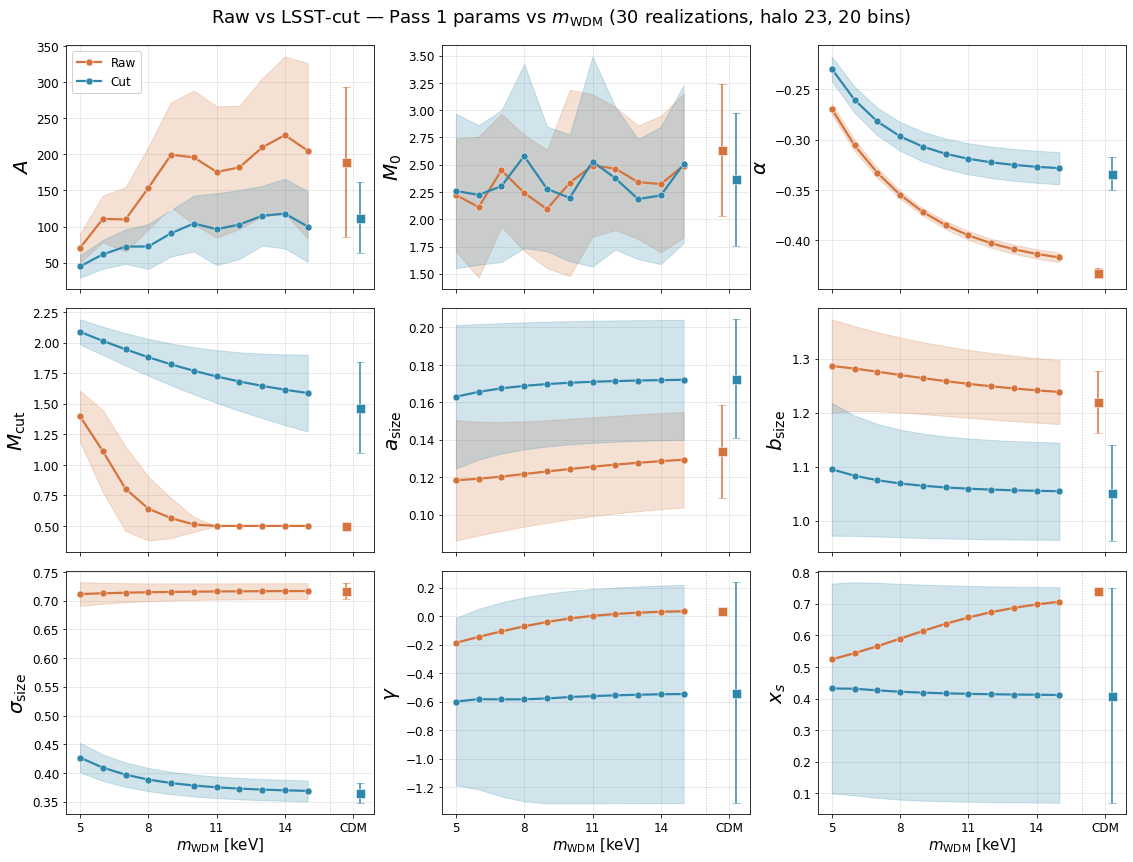

Cell Completed


In [7]:
# %%
print("Cell Initiated")
# =============================================================================
# RAW vs LSST-CUT: Pass-1 params vs m_WDM — 3×3 shared-x
# Loads mcut_scatter_raw_vs_cut_20bins.pkl (single pkl with data_type column)
# Blue = cut, Orange = raw. Mean line + 1σ band + CDM anchor for each.
# =============================================================================

import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import os

plt.rcParams.update({
    'font.size': 18, 'axes.titlesize': 24, 'axes.labelsize': 22,
    'xtick.labelsize': 18, 'ytick.labelsize': 18,
    'legend.fontsize': 16, 'figure.titlesize': 26,
})

PKL_PATH = './mcut_scatter_raw_vs_cut_20bins_compat.pkl'  # compat version
with open(PKL_PATH, 'rb') as f:
    d = pickle.load(f)
df = pd.DataFrame(d['results_df_dict'])
print(f"Loaded: {len(df)} rows, data_types = {sorted(df['data_type'].unique())}")

COSMO_NAMES = ['CDM'] + [f'WDM_{m}keV' for m in [5,6,7,8,9,10,11,12,13,14,15]]
MWDM_VALUES = [100.0, 5,6,7,8,9,10,11,12,13,14,15]
COSMO_TO_MWDM = dict(zip(COSMO_NAMES, MWDM_VALUES))
WDM_ONLY = [c for c in COSMO_NAMES if c != 'CDM']

PARAM_LATEX = [r'$A$', r'$M_0$', r'$\alpha$', r'$M_{\mathrm{cut}}$',
               r'$a_{\mathrm{size}}$', r'$b_{\mathrm{size}}$',
               r'$\sigma_{\mathrm{size}}$', r'$\gamma$', r'$x_s$']

# Two colors: orange for raw (background reference), blue for cut (main)
COLOR_RAW = '#D4733C'   # burnt orange
COLOR_CUT = '#2E86AB'   # blue
CDM_X_RAW = 16.7
CDM_X_CUT = 17.3


def _get_param_vs_mwdm(sub_df, idx):
    """Return x_plot, y_mean, y_std for param `idx` across WDM cosmologies."""
    x, m, s = [], [], []
    for cosmo in WDM_ONLY:
        sub = sub_df[sub_df['cosmo'] == cosmo]
        vals = [row['theta9_allfree'][idx] for _, row in sub.iterrows()
                if hasattr(row['theta9_allfree'], '__len__')
                and len(row['theta9_allfree']) == 9
                and np.isfinite(row['theta9_allfree'][idx])]
        if len(vals) == 0:
            continue
        vals = np.array(vals)
        x.append(COSMO_TO_MWDM[cosmo])
        m.append(np.mean(vals))
        s.append(np.std(vals))
    return np.array(x, dtype=float), np.array(m), np.array(s)


def _get_cdm(sub_df, idx):
    sub_cdm = sub_df[sub_df['cosmo'] == 'CDM']
    vals = [row['theta9_allfree'][idx] for _, row in sub_cdm.iterrows()
            if hasattr(row['theta9_allfree'], '__len__')
            and len(row['theta9_allfree']) == 9
            and np.isfinite(row['theta9_allfree'][idx])]
    if len(vals) == 0:
        return None, None
    vals = np.array(vals)
    return np.mean(vals), np.std(vals)


fig, axes = plt.subplots(3, 3, figsize=(16, 12), sharex=True)
axes = axes.ravel()

df_raw = df[df['data_type'] == 'raw']
df_cut = df[df['data_type'] == 'cut']

for idx, ax in enumerate(axes):
    # raw
    x_r, m_r, s_r = _get_param_vs_mwdm(df_raw, idx)
    ax.fill_between(x_r, m_r - s_r, m_r + s_r, alpha=0.22, color=COLOR_RAW, zorder=2)
    ax.plot(x_r, m_r, 'o-', color=COLOR_RAW, lw=2.2, ms=7,
            markeredgecolor='white', markeredgewidth=0.5, zorder=4,
            label='Raw' if idx == 0 else None)
    cdm_m, cdm_s = _get_cdm(df_raw, idx)
    if cdm_m is not None:
        ax.errorbar([CDM_X_RAW], [cdm_m], yerr=[cdm_s],
                    fmt='s', color=COLOR_RAW, ms=9, capsize=4, capthick=2,
                    markeredgecolor='white', markeredgewidth=0.5, zorder=5)

    # cut
    x_c, m_c, s_c = _get_param_vs_mwdm(df_cut, idx)
    ax.fill_between(x_c, m_c - s_c, m_c + s_c, alpha=0.22, color=COLOR_CUT, zorder=2)
    ax.plot(x_c, m_c, 'o-', color=COLOR_CUT, lw=2.2, ms=7,
            markeredgecolor='white', markeredgewidth=0.5, zorder=4,
            label='Cut' if idx == 0 else None)
    cdm_m, cdm_s = _get_cdm(df_cut, idx)
    if cdm_m is not None:
        ax.errorbar([CDM_X_CUT], [cdm_m], yerr=[cdm_s],
                    fmt='s', color=COLOR_CUT, ms=9, capsize=4, capthick=2,
                    markeredgecolor='white', markeredgewidth=0.5, zorder=5)

    ax.axvline(16.0, color='gray', ls=':', lw=1, alpha=0.5)
    ax.set_ylabel(PARAM_LATEX[idx], fontsize=20, labelpad=4)
    ax.set_xticks([5, 8, 11, 14, 17])
    ax.set_xticklabels(['5', '8', '11', '14', 'CDM'])
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=12)

    if idx >= 6:
        ax.set_xlabel(r'$m_{\mathrm{WDM}}$ [keV]', fontsize=15, labelpad=2)

    if idx == 0:
        ax.legend(fontsize=12, loc='best', framealpha=0.9)

fig.suptitle('Raw vs LSST-cut — Pass 1 params vs $m_{\\mathrm{WDM}}$ (30 realizations, halo 23, 20 bins)',
             fontsize=18, y=0.995)
plt.subplots_adjust(left=0.07, right=0.99, top=0.95, bottom=0.06,
                    wspace=0.22, hspace=0.08)

output_path = 'raw_vs_cut_params_3x3.png'
plt.savefig(output_path, dpi=200, bbox_inches='tight')
print(f"  Saved: {output_path}")

plt.show()
plt.close()

print("Cell Completed")

In [8]:
print("Cell Initiated")
# =============================================================================
# Full numeric readout — all 9 params × 12 cosmologies, raw + cut side-by-side
# =============================================================================

param_names = ['A', 'M_0', 'alpha', 'M_cut', 'a_size', 'b_size',
               'sigma_size', 'gamma', 'x_s']

for idx, pname in enumerate(param_names):
    print(f"\n### {pname}\n")
    print(f"| Cosmology  | raw mean | raw σ  | cut mean | cut σ  |")
    print(f"|------------|----------|--------|----------|--------|")
    for cosmo in COSMO_NAMES:
        row_str = f"| {cosmo:<10} |"
        for dt in ['raw', 'cut']:
            sub = df[(df['cosmo'] == cosmo) & (df['data_type'] == dt)]
            vals = [r['theta9_allfree'][idx] for _, r in sub.iterrows()
                    if hasattr(r['theta9_allfree'], '__len__')
                    and len(r['theta9_allfree']) == 9
                    and np.isfinite(r['theta9_allfree'][idx])]
            if len(vals) == 0:
                row_str += " --       | --     |"
                continue
            vals = np.array(vals)
            row_str += f" {np.mean(vals):>8.4f} | {np.std(vals):>6.4f} |"
        print(row_str)

print("\nCell Completed")

Cell Initiated

### A

| Cosmology  | raw mean | raw σ  | cut mean | cut σ  |
|------------|----------|--------|----------|--------|
| CDM        | 189.3985 | 103.8357 | 112.0541 | 49.2747 |
| WDM_5keV   |  70.2683 | 20.1547 |  44.7088 | 15.6458 |
| WDM_6keV   | 110.5891 | 32.3834 |  61.4175 | 19.9656 |
| WDM_7keV   | 109.8149 | 44.5292 |  72.2024 | 23.8655 |
| WDM_8keV   | 153.5158 | 57.1674 |  72.3601 | 31.2115 |
| WDM_9keV   | 199.5670 | 72.8005 |  90.7028 | 32.2366 |
| WDM_10keV  | 195.8788 | 92.5479 | 104.2100 | 38.8693 |
| WDM_11keV  | 175.6923 | 91.0010 |  96.3492 | 49.7246 |
| WDM_12keV  | 181.9845 | 85.4540 | 102.7513 | 47.8620 |
| WDM_13keV  | 209.6903 | 95.9117 | 114.9711 | 41.4086 |
| WDM_14keV  | 226.7583 | 108.9540 | 117.9007 | 48.3077 |
| WDM_15keV  | 205.1711 | 121.5506 | 100.0414 | 49.0770 |

### M_0

| Cosmology  | raw mean | raw σ  | cut mean | cut σ  |
|------------|----------|--------|----------|--------|
| CDM        |   2.6338 | 0.6062 |   2.3667 | 0.6115 |
| WDM